# LushProtein — Decile: Profit & Order Frequency (5 Aggregated Deciles)

**Goal:** Re-decile customers using the founder's requested formula, on the freshly cleaned `outputs_finals/` data.

**Profit formula (as scoped with the founder):**
```
Profit = Net Revenue − COGS
```
Variable Fulfillment Costs and Refunds are **excluded** — no reliable per-order data exists for either
(see markdown notes below for why). Discounts are **already netted into revenue** by Shopify's export format,
so no separate subtraction is needed.

**Two independent decile rankings, both D1–D5 (not D1–D10 like draft 1):**
- **Profit Decile** — ranked by `true_gross_profit` (Revenue − COGS). D1 = highest.
- **Order Frequency (AOF) Decile** — ranked by `finals_orders` (number of orders placed). D1 = most frequent.

**Customer pool:** `finals_eligible == True` AND NOT 100%-Marketplace accounts (see Section 2 for why).

---

### Why D1–D5 instead of D1–D10 this time

With a pool of ~4,290 customers after filtering customers, 5 merged segments still give ~858 customers per group, 
large enough for reliable analysis, and simpler for non-technical stakeholders to act on 
(5 customer segments are easier to build campaigns around than 10).

### Why no Fulfillment Cost or Refund terms

- **Variable Fulfillment Costs**: no pick/pack/ship cost-per-order data exists anywhere in the dataset.
  `Price: Total Shipping` is what the *customer paid*, not what it *cost* LushProtein to fulfill — using it
  would misrepresent fulfillment cost as fulfillment revenue. Excluded until the founder provides a real figure.
- **Refunds**: no refund dollar amount exists. Only a binary signal (`Payment: Status == 'partially_refunded'`,
  61 orders) is available, with no associated amount. Excluded until quantifiable.

### Why discounts need no separate subtraction

Shopify's `Price: Total` field is **already net of discounts** at export time — it is calculated as
`(unit price × quantity) − discount`, not the pre-discount sticker price. You can verify this yourself:
`orders["Price: Total"] + orders["Price: Total Discount"]` reconstructs the pre-discount price, which only
makes sense if `Price: Total` was already reduced by the discount. So "Net Revenue" in the formula is simply
`Price: Total` as-is — no further adjustment needed.


## 0. Setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR   = Path(".").resolve().parent   # assumes notebook is inside EDA/
FINALS_DIR = BASE_DIR / "EDA" / "outputs_finals"

N_SEG = 5

print("Finals dir:", FINALS_DIR)
print("Parquet files:", [f.name for f in FINALS_DIR.glob("*.parquet")])

Finals dir: C:\Users\saeli\Downloads\LushProtein prj\lushprotein\EDA\outputs_finals
Parquet files: ['customers.parquet', 'discounts.parquet', 'lines.parquet', 'lines_sku_analysis.parquet', 'orders.parquet', 'products.parquet', 'rc_checkout.parquet', 'rc_churned.parquet', 'rc_orders.parquet', 'rc_reactivated.parquet', 'rc_recurring.parquet']


## 1. Load Pre-Cleaned Data

No DQ cleaning needed here — `outputs_finals/` is already cleaned (DQ-02/03/04, LP-F01–F04, COGS-enriched
by `13_build_finals_datasets.py` + `enrich_finals_with_margin.py`). We only load and inspect.

In [3]:
orders = pd.read_parquet(FINALS_DIR / "orders.parquet")
cust   = pd.read_parquet(FINALS_DIR / "customers.parquet")

print(f"Orders (finals, COGS-enriched) : {len(orders):,}")
print(f"Customers (finals, COGS-enriched): {len(cust):,}")
print()
print(f"finals_eligible customers : {(cust['finals_eligible']==True).sum():,}")
print()
print("Key columns already present:")
print(" true_gross_profit — Revenue minus COGS, our profit base")
print(" finals_orders — order count within the finals-eligible window (our AOF metric)")
print(" cogs_coverage_pct — % of this customer's revenue that has real COGS (vs 40% proxy fallback)")

Orders (finals, COGS-enriched) : 8,955
Customers (finals, COGS-enriched): 5,694

finals_eligible customers : 5,694

Key columns already present:
 true_gross_profit — Revenue minus COGS, our profit base
 finals_orders — order count within the finals-eligible window (our AOF metric)
 cogs_coverage_pct — % of this customer's revenue that has real COGS (vs 40% proxy fallback)


## 2. Marketplace Exclusion — Why and How

**The problem:** `outputs_finals/` is cleaned for data-quality and business-rule issues (DQ drops, promo
months, bulk SKU, heavy discounts) — but it does **not** exclude 100%-Marketplace (Shopee/Lazada) accounts.
We need to check and reapply this ourselves, same as draft 1.

**Why it matters — concrete example below.**

In [4]:
# ── Channel mix per customer ───────────────────────────────────────────────────
cust_channel_mix = (orders.groupby("customer_id")["channel"].value_counts(normalize=True).unstack(fill_value=0))

all_marketplace_ids = set(cust_channel_mix[cust_channel_mix.get("Marketplace", pd.Series(0, index=cust_channel_mix.index)) == 1.0].index.astype(str))

cust["is_all_marketplace"] = cust["customer_id"].astype(str).isin(all_marketplace_ids)

print(f"Channel breakdown of all orders:")
print(orders["channel"].value_counts().to_string())
print()
print(f"Customers with 100% Marketplace orders : {len(all_marketplace_ids):,}")
print(f"Of finals_eligible customers, all-marketplace : {(cust['finals_eligible'] & cust['is_all_marketplace']).sum():,}")

Channel breakdown of all orders:
channel
Direct / Organic    3293
Subscription        3044
Marketplace         2167
Paid Social          373
Email                 52
Affiliate             23
Paid Search            3

Customers with 100% Marketplace orders : 1,404
Of finals_eligible customers, all-marketplace : 1,404


### Concrete Example — Why This Customer Cannot Be Treated as a Real Consumer

Below is the single largest all-Marketplace account in the dataset. Notice:
- **524 separate orders**, each with its own unique `order_id`
- **Multiple orders placed on the exact same day**, repeated daily for months
- **Order values swing wildly** (S$29.90 to S$438 in the same week) — no personal buying rhythm

No single human shopper behaves like this. This is the fingerprint of a Shopee storefront account
absorbing many different real buyers' orders into one Shopify `customer_id` — not one loyal customer.

In [5]:
mkt_orders = orders[orders["channel"] == "Marketplace"].copy()

orders_per_mkt_cust = mkt_orders.groupby("customer_id")["order_id"].count()
print("Orders-per-customer distribution among Marketplace accounts:")
print(orders_per_mkt_cust.describe().to_string())
print()
print(f" Median = {orders_per_mkt_cust.median():.0f} order  →  most are genuine one-time Shopee shoppers")
print(f" Max = {orders_per_mkt_cust.max():.0f} orders →  but extreme outliers exist (aggregator pattern)")
print()

# Show the worst offender as a concrete example
top_mkt_cust = orders_per_mkt_cust.idxmax()
example = mkt_orders[mkt_orders["customer_id"] == top_mkt_cust][["order_id", "order_date", "Price: Total", "Name"]].sort_values("order_date").head(10)

print(f"EXAMPLE — customer_id {top_mkt_cust} ({orders_per_mkt_cust.max()} total orders):")
print(example.to_string(index=False))
print("...")
print(f"\nDecision: exclude ALL {len(all_marketplace_ids):,} all-Marketplace customers from the decile pool")
print("(consistent with draft 1 methodology — simplicity over trying to separate the few outliers from genuine one-time buyers)")

Orders-per-customer distribution among Marketplace accounts:
count    1404.000000
mean        1.543447
std        13.964530
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       524.000000

 Median = 1 order  →  most are genuine one-time Shopee shoppers
 Max = 524 orders →  but extreme outliers exist (aggregator pattern)

EXAMPLE — customer_id 7888450879743 (524 total orders):
     order_id                order_date  Price: Total     Name
6038114042111 2025-03-05 16:00:00+00:00          29.9 LP-42767
6038154445055 2025-03-05 16:00:00+00:00         119.0 LP-42769
6038155100415 2025-03-05 16:00:00+00:00          59.8 LP-42770
6038210871551 2025-03-05 16:00:00+00:00         238.0 LP-42773
6038301638911 2025-03-05 16:00:00+00:00          89.9 LP-42774
6038351249663 2025-03-05 16:00:00+00:00         219.0 LP-42775
6039815487743 2025-03-06 16:00:00+00:00         438.0 LP-42788
6040719524095 2025-03-07 16:00:00+00:00         169.9 LP-42795
6041123848447

## 3. Build the Final Customer Pool

In [6]:
f_finals_eligible = cust["finals_eligible"] == True
f_not_marketplace = ~cust["is_all_marketplace"]

final_mask = f_finals_eligible & f_not_marketplace
df = cust[final_mask].copy()

print("Filter funnel:")
print(f"  Base customers (outputs_finals) : {len(cust):>6,}")
print(f"  finals_eligible : {f_finals_eligible.sum():>6,}")
print(f"  - excl. all-marketplace accounts : {final_mask.sum():>6,}")
print(f"  ─────────────────────────────────────────────")
print(f"  Final decile pool : {len(df):>6,} customers")
print()
print(f"Profit range : S${df['true_gross_profit'].min():,.2f} – S${df['true_gross_profit'].max():,.2f}")
print(f"Order count range : {df['finals_orders'].min()} – {df['finals_orders'].max()}")
print()
neg_count = (df["true_gross_profit"] < 0).sum()
print(f"Note: {neg_count} customers have negative profit margin")
print(" (sold below cost — likely loss-leader/promo SKUs with thin or negative real margin)")

Filter funnel:
  Base customers (outputs_finals) :  5,694
  finals_eligible :  5,694
  - excl. all-marketplace accounts :  4,290
  ─────────────────────────────────────────────
  Final decile pool :  4,290 customers

Profit range : S$-29.93 – S$2,796.69
Order count range : 1 – 38

Note: 9 customers have negative profit margin
 (sold below cost — likely loss-leader/promo SKUs with thin or negative real margin)


## 4. Build the Two Deciles (5 Segmetnations Each)

D1 = best (highest profit / most frequent orders) in both. Equal-sized groups via `pd.qcut` on ranks.

In [7]:
def assign_decile(series: pd.Series, n_seg: int = N_SEG) -> pd.Series:
    """D1 = best (highest value), D[n] = worst. Ties broken deterministically."""
    ranks = series.rank(method="first", ascending=True)
    return pd.qcut(
        ranks,
        q=n_seg,
        labels=[f"D{i}" for i in range(n_seg, 0, -1)])

df["profit_decile"] = assign_decile(df["true_gross_profit"])
df["order_freq_decile"] = assign_decile(df["finals_orders"])

print("Profit Decile distribution:")
print(df["profit_decile"].value_counts().sort_index().to_string())
print()
print("Order Frequency Decile distribution:")
print(df["order_freq_decile"].value_counts().sort_index().to_string())

Profit Decile distribution:
profit_decile
D5    858
D4    858
D3    858
D2    858
D1    858

Order Frequency Decile distribution:
order_freq_decile
D5    858
D4    858
D3    858
D2    858
D1    858


## 5. Decile Summary — Profit

In [8]:
profit_summary = (
    df.groupby("profit_decile", observed=False)
    .agg(
        n_customers = ("customer_id", "count"),
        total_profit = ("true_gross_profit", "sum"),
        avg_profit = ("true_gross_profit", "mean"),
        median_profit = ("true_gross_profit", "median"),
        avg_revenue = ("finals_revenue", "mean"),
        avg_orders = ("finals_orders", "mean"),
        avg_margin_pct = ("avg_margin_pct", "mean"),).reset_index())

total_profit_pool = profit_summary["total_profit"].sum()
profit_summary["pct_of_total_profit"] = profit_summary["total_profit"] / total_profit_pool
profit_summary["cum_pct_profit"]      = profit_summary["pct_of_total_profit"].cumsum()

fmt_profit = {
    "avg_profit": lambda x: f"S${x:,.2f}",
    "median_profit": lambda x: f"S${x:,.2f}",
    "avg_revenue": lambda x: f"S${x:,.2f}",
    "avg_orders": lambda x: f"{x:.1f}",
    "avg_margin_pct": lambda x: f"{x:.1%}",
    "pct_of_total_profit":lambda x: f"{x:.1%}",
    "cum_pct_profit": lambda x: f"{x:.1%}",}

print(f"DECILE — BY PROFIT  (pool = {len(df):,} customers | total profit = S${total_profit_pool:,.0f})")
print()
display_cols_profit = ["profit_decile", "n_customers", "avg_profit", "median_profit", "avg_revenue", "avg_orders", "avg_margin_pct", "pct_of_total_profit", "cum_pct_profit"]
print(profit_summary[display_cols_profit].to_string(index=False, formatters=fmt_profit))
print()
d1_pct = profit_summary.loc[profit_summary["profit_decile"]=="D1", "pct_of_total_profit"].values[0]
print(f" Top 20% (D1) of customers generate {d1_pct:.1%} of total profit")

DECILE — BY PROFIT  (pool = 4,290 customers | total profit = S$341,853)

profit_decile  n_customers avg_profit median_profit avg_revenue avg_orders avg_margin_pct pct_of_total_profit cum_pct_profit
           D5          858     S$8.87        S$8.02     S$19.25        1.1          49.3%                2.2%           2.2%
           D4          858    S$29.66       S$28.74     S$52.75        1.1          60.7%                7.4%           9.7%
           D3          858    S$48.59       S$48.41     S$74.48        1.2          69.3%               12.2%          21.9%
           D2          858    S$81.25       S$80.92    S$122.04        1.5          70.5%               20.4%          42.3%
           D1          858   S$230.05      S$164.25    S$374.69        3.1          69.1%               57.7%         100.0%

 Top 20% (D1) of customers generate 57.7% of total profit


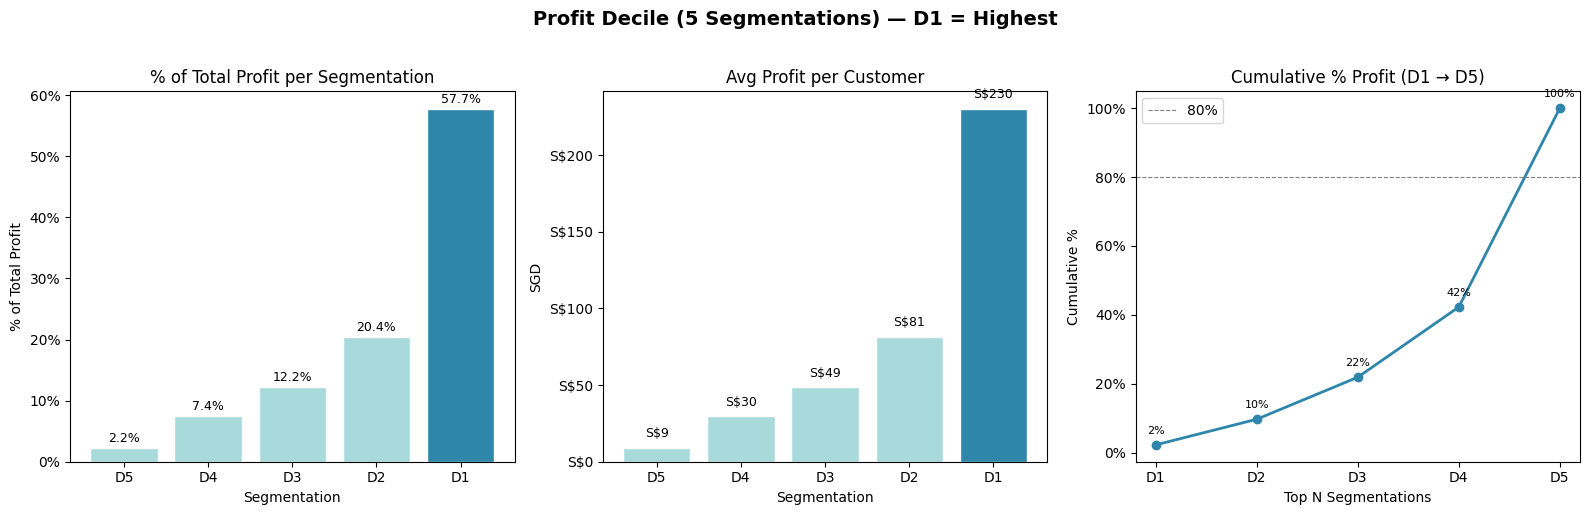

Saved: decile_profit.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Profit Decile (5 Segmentations) — D1 = Highest", fontsize=14, fontweight="bold", y=1.02)

seg_profit = profit_summary["profit_decile"].astype(str)
colors_profit = ["#2E86AB" if t == "D1" else "#A8DADC" for t in seg_profit]

ax = axes[0]
bars = ax.bar(seg_profit, profit_summary["pct_of_total_profit"] * 100, color=colors_profit, edgecolor="white")
ax.set_title("% of Total Profit per Segmentation")
ax.set_xlabel("Segmentation"); ax.set_ylabel("% of Total Profit")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for bar, val in zip(bars, profit_summary["pct_of_total_profit"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f"{val:.1%}", ha="center", va="bottom", fontsize=9)

ax = axes[1]
bars = ax.bar(seg_profit, profit_summary["avg_profit"], color=colors_profit, edgecolor="white")
ax.set_title("Avg Profit per Customer")
ax.set_xlabel("Segmentation"); ax.set_ylabel("SGD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S${x:,.0f}"))
for bar, val in zip(bars, profit_summary["avg_profit"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, f"S${val:,.0f}", ha="center", va="bottom", fontsize=9)

ax = axes[2]
ax.plot(range(1,  N_SEG+1), profit_summary["cum_pct_profit"] * 100, marker="o", color="#2E86AB", linewidth=2)
ax.axhline(80, color="gray", linestyle="--", linewidth=0.8, label="80%")
ax.set_title("Cumulative % Profit (D1 → D5)")
ax.set_xlabel("Top N Segmentations"); ax.set_ylabel("Cumulative %")
ax.set_xticks(range(1,  N_SEG+1)); ax.set_xticklabels([f"D{i}" for i in range(1,  N_SEG+1)])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend()
for x, y in zip(range(1,  N_SEG+1), profit_summary["cum_pct_profit"] * 100):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(FINALS_DIR / "decile_profit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: decile_profit.png")

## 6. Decile Summary — Order Frequency (AOF)

In [10]:
freq_summary = (
    df.groupby("order_freq_decile", observed=False)
    .agg(
        n_customers = ("customer_id", "count"),
        total_orders = ("finals_orders", "sum"),
        avg_orders = ("finals_orders", "mean"),
        median_orders = ("finals_orders", "median"),
        avg_revenue = ("finals_revenue", "mean"),
        avg_profit = ("true_gross_profit", "mean"),
        avg_margin_pct= ("avg_margin_pct", "mean"),).reset_index())

total_orders_pool = freq_summary["total_orders"].sum()
freq_summary["pct_of_total_orders"] = freq_summary["total_orders"] / total_orders_pool
freq_summary["cum_pct_orders"]      = freq_summary["pct_of_total_orders"].cumsum()

fmt_freq = {
    "avg_orders": lambda x: f"{x:.1f}",
    "median_orders": lambda x: f"{x:.0f}",
    "avg_revenue": lambda x: f"S${x:,.2f}",
    "avg_profit": lambda x: f"S${x:,.2f}",
    "avg_margin_pct": lambda x: f"{x:.1%}",
    "pct_of_total_orders": lambda x: f"{x:.1%}",
    "cum_pct_orders": lambda x: f"{x:.1%}",
}

print(f"DECILE — BY ORDER FREQUENCY (AOF)  (pool = {len(df):,} customers | total orders = {total_orders_pool:,})")
print()
display_cols_freq = ["order_freq_decile", "n_customers", "avg_orders", "median_orders", "avg_revenue", "avg_profit", "avg_margin_pct", "pct_of_total_orders", "cum_pct_orders"]
print(freq_summary[display_cols_freq].to_string(index=False, formatters=fmt_freq))
print()
d1_ord_pct = freq_summary.loc[freq_summary["order_freq_decile"]=="D1", "pct_of_total_orders"].values[0]
print(f" Top 20% (D1) of customers place {d1_ord_pct:.1%} of all orders")

DECILE — BY ORDER FREQUENCY (AOF)  (pool = 4,290 customers | total orders = 6,788)

order_freq_decile  n_customers avg_orders median_orders avg_revenue avg_profit avg_margin_pct pct_of_total_orders cum_pct_orders
               D5          858        1.0             1     S$93.22    S$55.78          62.8%               12.6%          12.6%
               D4          858        1.0             1     S$68.19    S$38.99          56.6%               12.6%          25.3%
               D3          858        1.0             1     S$58.75    S$42.75          67.6%               12.6%          37.9%
               D2          858        1.3             1    S$125.77    S$80.31          68.9%               16.6%          54.6%
               D1          858        3.6             3    S$297.30   S$180.60          62.9%               45.4%         100.0%

 Top 20% (D1) of customers place 45.4% of all orders


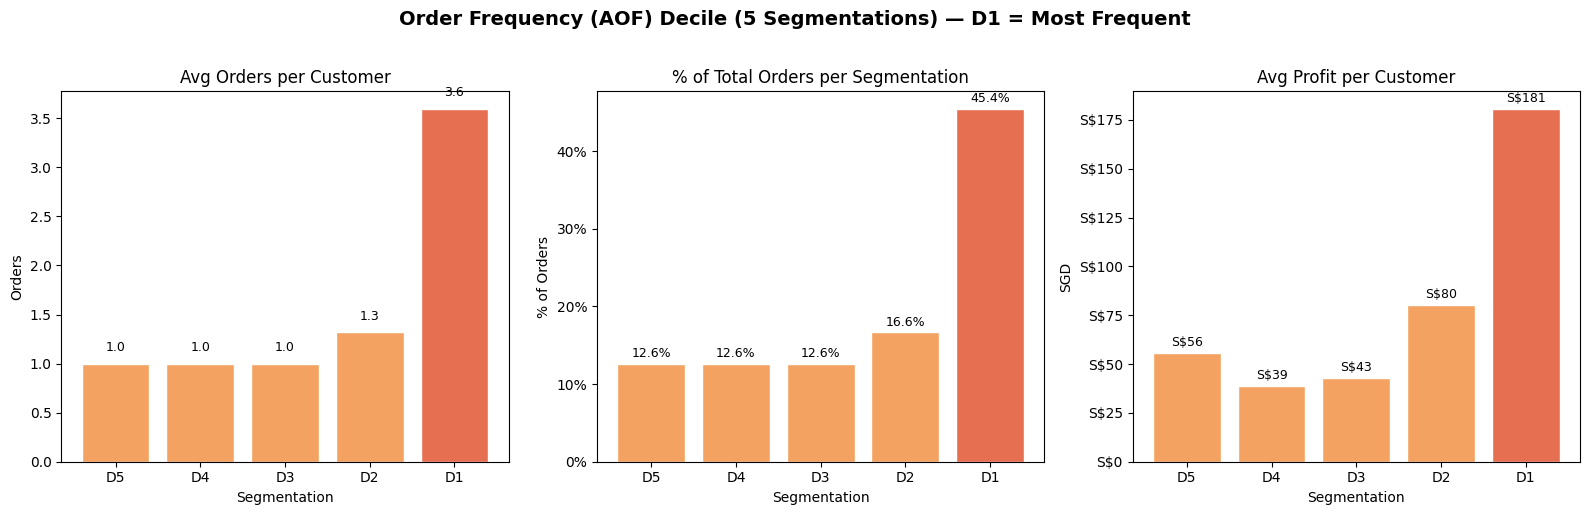

Saved: decile_order_frequency.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Order Frequency (AOF) Decile (5 Segmentations) — D1 = Most Frequent", fontsize=14, fontweight="bold", y=1.02)

seg_f = freq_summary["order_freq_decile"].astype(str)
colors_f = ["#E76F51" if t == "D1" else "#F4A261" for t in seg_f]

ax = axes[0]
bars = ax.bar(seg_f, freq_summary["avg_orders"], color=colors_f, edgecolor="white")
ax.set_title("Avg Orders per Customer")
ax.set_xlabel("Segmentation"); ax.set_ylabel("Orders")
for bar, val in zip(bars, freq_summary["avg_orders"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f"{val:.1f}", ha="center", va="bottom", fontsize=9)

ax = axes[1]
bars = ax.bar(seg_f, freq_summary["pct_of_total_orders"] * 100, color=colors_f, edgecolor="white")
ax.set_title("% of Total Orders per Segmentation")
ax.set_xlabel("Segmentation"); ax.set_ylabel("% of Orders")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for bar, val in zip(bars, freq_summary["pct_of_total_orders"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f"{val:.1%}", ha="center", va="bottom", fontsize=9)

ax = axes[2]
bars = ax.bar(seg_f, freq_summary["avg_profit"], color=colors_f, edgecolor="white")
ax.set_title("Avg Profit per Customer")
ax.set_xlabel("Segmentation"); ax.set_ylabel("SGD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S${x:,.0f}"))
for bar, val in zip(bars, freq_summary["avg_profit"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f"S${val:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(FINALS_DIR / "decile_order_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: decile_order_frequency.png")

## 7. Overlap — Profit D1 vs Order Frequency D1

D1 Profit only : 858 customers (20.0% of pool)
D1 Order frequency only : 858 customers (20.0% of pool)
D1 BOTH : 500 customers (11.7% of pool)



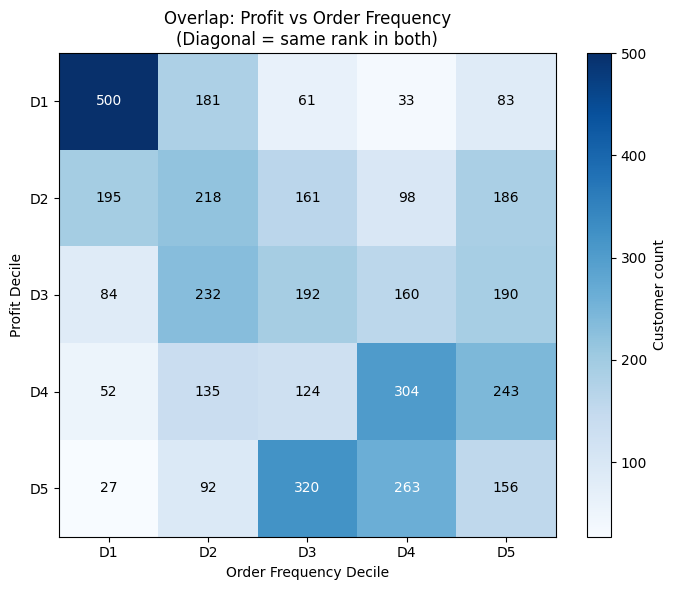

Saved: decile_overlap_heatmap.png


In [12]:
d1_profit   = set(df[df["profit_decile"] == "D1"]["customer_id"])
d1_freq = set(df[df["order_freq_decile"] == "D1"]["customer_id"])
d1_both = d1_profit & d1_freq

n_pool = len(df)
print(f"D1 Profit only : {len(d1_profit):,} customers ({len(d1_profit)/n_pool:.1%} of pool)")
print(f"D1 Order frequency only : {len(d1_freq):,} customers ({len(d1_freq)/n_pool:.1%} of pool)")
print(f"D1 BOTH : {len(d1_both):,} customers ({len(d1_both)/n_pool:.1%} of pool)")
print()

# Cross-tab heatmap
cross = pd.crosstab(df["profit_decile"], df["order_freq_decile"], margins=False)
all_seg = [f"D{i}" for i in range(1, N_SEG+1)]
cross = cross.reindex(index=all_seg, columns=all_seg, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cross.values, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="Customer count")
ax.set_xticks(range(N_SEG)); ax.set_yticks(range(N_SEG))
ax.set_xticklabels(all_seg); ax.set_yticklabels(all_seg)
ax.set_xlabel("Order Frequency Decile")
ax.set_ylabel("Profit Decile")
ax.set_title("Overlap: Profit vs Order Frequency\n(Diagonal = same rank in both)")
for i in range(N_SEG):
    for j in range(N_SEG):
        val = cross.values[i, j]
        ax.text(j, i, str(val), ha="center", va="center", fontsize=10,
                 color="white" if val > cross.values.max()*0.5 else "black")

plt.tight_layout()
plt.savefig(FINALS_DIR / "decile_overlap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: decile_overlap_heatmap.png")

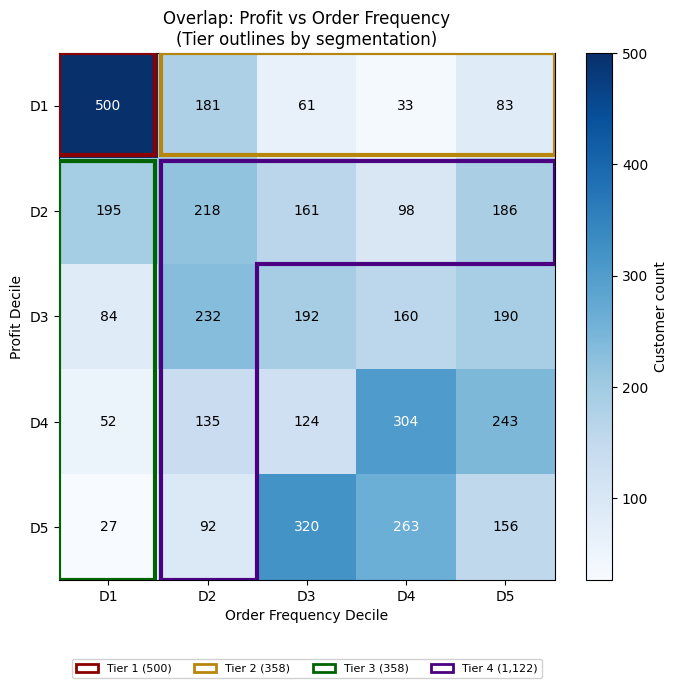

Saved: decile_overlap_heatmap.png (with tier outlines)


In [13]:
# ── Annotated heatmap: tier outlines overlaid ────────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon

# Compute tier counts (d1_profit / d1_freq in scope from cell above)
_t1 = len(d1_profit & d1_freq)
_t2 = len(d1_profit - d1_freq)
_t3 = len(d1_freq - d1_profit)
_d2p = set(df[df["profit_decile"] == "D2"]["customer_id"])
_d2f = set(df[df["order_freq_decile"] == "D2"]["customer_id"])
_t4 = len((_d2p | _d2f) - d1_profit - d1_freq)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(cross.values, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="Customer count")
ax.set_xticks(range(N_SEG)); ax.set_yticks(range(N_SEG))
ax.set_xticklabels(all_seg); ax.set_yticklabels(all_seg)
ax.set_xlabel("Order Frequency Decile")
ax.set_ylabel("Profit Decile")
ax.set_title("Overlap: Profit vs Order Frequency" + chr(10) + "(Tier outlines by segmentation)")
for i in range(N_SEG):
    for j in range(N_SEG):
        val = cross.values[i, j]
        ax.text(j, i, str(val), ha="center", va="center", fontsize=10,
                color="white" if val > cross.values.max() * 0.5 else "black")

LW = 3
D = 0.03  # inset on shared borders so both tier colors remain visible

# Tier 1: D1 Profit & D1 Freq — inset right (shared w/ T2) and bottom (shared w/ T3)
ax.add_patch(plt.Rectangle((-0.5, -0.5), 1 - D, 1 - D,
             fill=False, edgecolor="#8B0000", linewidth=LW, zorder=5))

# Tier 2: D1 Profit only — inset left (shared w/ T1) and bottom (shared w/ T4)
ax.add_patch(plt.Rectangle((0.5 + D, -0.5), 4 - D, 1 - D,
             fill=False, edgecolor="#B8860B", linewidth=LW, zorder=5))

# Tier 3: D1 Freq only — inset top (shared w/ T1) and right (shared w/ T4)
ax.add_patch(plt.Rectangle((-0.5, 0.5 + D), 1 - D, 4 - D,
             fill=False, edgecolor="#006400", linewidth=LW, zorder=5))

# Tier 4: D2 Profit or Freq — L-shape, inset top (shared w/ T2) and left (shared w/ T3)
ax.add_patch(MplPolygon(
    [(0.5 + D, 0.5 + D), (4.5, 0.5 + D), (4.5, 1.5),
     (1.5, 1.5), (1.5, 4.5), (0.5 + D, 4.5)],
    closed=True, fill=False, edgecolor="#4B0082", linewidth=LW, zorder=5
))

legend_handles = [
    mpatches.Patch(facecolor="none", edgecolor="#8B0000", linewidth=2,
                   label=f"Tier 1 ({_t1:,})"),
    mpatches.Patch(facecolor="none", edgecolor="#B8860B", linewidth=2,
                   label=f"Tier 2 ({_t2:,})"),
    mpatches.Patch(facecolor="none", edgecolor="#006400", linewidth=2,
                   label=f"Tier 3 ({_t3:,})"),
    mpatches.Patch(facecolor="none", edgecolor="#4B0082", linewidth=2,
                   label=f"Tier 4 ({_t4:,})"),
]
ax.legend(handles=legend_handles, loc="upper center",
          bbox_to_anchor=(0.5, -0.14), ncol=4, fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig(FINALS_DIR / "decile_overlap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: decile_overlap_heatmap.png (with tier outlines)")

## 8. Export: Customer-Level Decile Table

In [14]:
export_cols = [
    "customer_id",
    "finals_orders", "finals_revenue", "true_gross_profit", "avg_margin_pct", "cogs_coverage_pct",
    "profit_decile", "order_freq_decile",
]
for col in ["first_channel", "first_product_cat", "first_store", "ever_subscribed",
            "cohort_month", "acq_year", "n_categories_ever"]:
    if col in df.columns:
        export_cols.append(col)

export_df = df[export_cols].copy()
export_df = export_df.sort_values(
    ["profit_decile", "true_gross_profit"], ascending=[True, False]
)

export_df["is_top_profit"]   = export_df["profit_decile"] == "D1"
export_df["is_top_freq"] = export_df["order_freq_decile"]          == "D1"
export_df["is_top_both"] = export_df["is_top_profit"] & export_df["is_top_freq"]

for col in ["finals_revenue", "true_gross_profit"]:
    export_df[col] = export_df[col].round(2)
export_df["avg_margin_pct"]    = (export_df["avg_margin_pct"] * 100).round(1)
export_df["cogs_coverage_pct"] = (export_df["cogs_coverage_pct"] * 100).round(1)

out_path = FINALS_DIR / "decile_customer_table.csv"
export_df.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(f"Rows: {len(export_df):,}")
print()
print("Preview (top 10 by profit):")
display(export_df[export_df["profit_decile"]=="D1"].head(10))

Saved: C:\Users\saeli\Downloads\LushProtein prj\lushprotein\EDA\outputs_finals\decile_customer_table.csv
Rows: 4,290

Preview (top 10 by profit):


,customer_id,finals_orders,finals_revenue,true_gross_profit,avg_margin_pct,cogs_coverage_pct,profit_decile,order_freq_decile,first_channel,first_product_cat,first_store,ever_subscribed,cohort_month,acq_year,n_categories_ever,is_top_profit,is_top_freq,is_top_both
1666,7755957895423,38,4995.46,2796.69,56.0,62.9,D1,D1,Direct / Organic,Unknown,MY,True,2022-03,2022,4,True,True,True
336,6336728531199,3,5542.97,2215.23,40.0,0.0,D1,D1,Subscription,Unknown,SG,False,2022-05,2022,1,True,True,True
619,6558688313599,10,2783.08,1824.82,65.6,53.4,D1,D1,Direct / Organic,Unknown,MY,True,2022-05,2022,3,True,True,True
1736,7756000690431,4,3612.43,1817.95,50.3,29.9,D1,D1,Direct / Organic,Unknown,MY,False,2022-06,2022,2,True,True,True
293,6336631275775,2,4378.26,1751.30,40.0,0.0,D1,D2,Subscription,Unknown,SG,False,2022-04,2022,1,True,False,False
1884,7756026904831,5,4306.38,1722.55,40.0,0.0,D1,D1,Direct / Organic,Unknown,MY,False,2022-02,2022,1,True,True,True
344,6336747438335,5,3180.03,1544.83,48.6,28.1,D1,D1,Subscription,Unknown,SG,False,2022-08,2022,4,True,True,True
3685,8081852530943,7,1933.20,1500.97,77.6,100.0,D1,D1,Direct / Organic,Clear Protein,SG,False,2025-05,2025,3,True,True,True
222,6329689735423,13,2177.98,1431.60,65.7,57.9,D1,D1,Direct / Organic,Unknown,MY,False,2022-03,2022,4,True,True,True
1836,7756016877823,2,2763.27,1105.31,40.0,0.0,D1,D2,Direct / Organic,Unknown,MY,False,2022-08,2022,1,True,False,False


## 9. Summary

In [15]:
print("=" * 65)
print("LUSHPROTEIN DECILE — SUMMARY")
print("=" * 65)
print(f"\nCustomer pool (finals_eligible, excl. all-marketplace): {len(df):,}")
print(f"5 segmentations, ~{len(df)//5} customers per segmentation")

print("\n--- D1: BY PROFIT ---")
d1c = profit_summary[profit_summary["profit_decile"]=="D1"].iloc[0]
print(f" Customers : {d1c['n_customers']:,}")
print(f" Avg profit : S${d1c['avg_profit']:,.2f}")
print(f" Avg orders : {d1c['avg_orders']:.1f}")
print(f" % of total profit : {d1c['pct_of_total_profit']:.1%}")

print("\n--- D1: BY ORDER FREQUENCY (AOF) ---")
d1f = freq_summary[freq_summary["order_freq_decile"]=="D1"].iloc[0]
print(f"  Customers : {d1f['n_customers']:,}")
print(f"  Avg orders : {d1f['avg_orders']:.1f}")
print(f"  Avg profit : S${d1f['avg_profit']:,.2f}")
print(f"  % of total orders: {d1f['pct_of_total_orders']:.1%}")

print("\n--- OVERLAP ---")
print(f"  D1 in BOTH rankings: {len(d1_both):,} customers")

print("\n--- OUTPUTS ---")
print("  decile_customer_table.csv — full customer-level table, D1-D5 for both metrics")
print("  decile_profit.png — profit segmentation charts")
print("  decile_order_frequency.png — order frequency segmentation charts")
print("  decile_overlap_heatmap.png — cross-segmentation of Profit and Frequency")
print("=" * 65)

LUSHPROTEIN DECILE — SUMMARY

Customer pool (finals_eligible, excl. all-marketplace): 4,290
5 segmentations, ~858 customers per segmentation

--- D1: BY PROFIT ---
 Customers : 858
 Avg profit : S$230.05
 Avg orders : 3.1
 % of total profit : 57.7%

--- D1: BY ORDER FREQUENCY (AOF) ---
  Customers : 858
  Avg orders : 3.6
  Avg profit : S$180.60
  % of total orders: 45.4%

--- OVERLAP ---
  D1 in BOTH rankings: 500 customers

--- OUTPUTS ---
  decile_customer_table.csv — full customer-level table, D1-D5 for both metrics
  decile_profit.png — profit segmentation charts
  decile_order_frequency.png — order frequency segmentation charts
  decile_overlap_heatmap.png — cross-segmentation of Profit and Frequency


In [16]:
# ── TIER 1: Overlapping D1 customers (D1 in BOTH profit and frequency) ────────
d1_profit_ids = set(df[df["profit_decile"] == "D1"]["customer_id"])
d1_freq_ids   = set(df[df["order_freq_decile"] == "D1"]["customer_id"])

tier1_ids = d1_profit_ids & d1_freq_ids   # intersection = overlap

print(f"D1 (profit) customers     : {len(d1_profit_ids):,}")
print(f"D1 (frequency) customers  : {len(d1_freq_ids):,}")
print(f"TIER 1 (overlap, D1 both) : {len(tier1_ids):,}")

D1 (profit) customers     : 858
D1 (frequency) customers  : 858
TIER 1 (overlap, D1 both) : 500


In [17]:
# ── TIER 2: D1 (profit) customers, NOT already in Tier 1 ──────────────────────
tier2_ids = d1_profit_ids - tier1_ids

print(f"D1 (profit) customers total      : {len(d1_profit_ids):,}")
print(f"Already in Tier 1 (overlap)      : {len(tier1_ids):,}")
print(f"TIER 2 (D1 profit, not in T1)    : {len(tier2_ids):,}")

D1 (profit) customers total      : 858
Already in Tier 1 (overlap)      : 500
TIER 2 (D1 profit, not in T1)    : 358


In [18]:
# ── TIER 3: D1 (frequency) customers, NOT already in Tier 1 ───────────────────
tier3_ids = d1_freq_ids - tier1_ids

print(f"D1 (frequency) customers total   : {len(d1_freq_ids):,}")
print(f"Already in Tier 1 (overlap)      : {len(tier1_ids):,}")
print(f"TIER 3 (D1 freq, not in T1)      : {len(tier3_ids):,}")

D1 (frequency) customers total   : 858
Already in Tier 1 (overlap)      : 500
TIER 3 (D1 freq, not in T1)      : 358


In [19]:
# ── TIER 4: D2 customers (profit OR frequency), excluding anyone already in Tier 1-3 ──
d2_profit_ids = set(df[df["profit_decile"] == "D2"]["customer_id"])
d2_freq_ids   = set(df[df["order_freq_decile"] == "D2"]["customer_id"])

already_placed = tier1_ids | tier2_ids | tier3_ids

tier4_ids = (d2_profit_ids | d2_freq_ids) - already_placed

print(f"D2 (profit) customers        : {len(d2_profit_ids):,}")
print(f"D2 (frequency) customers     : {len(d2_freq_ids):,}")
print(f"D2 union (before exclusion)  : {len(d2_profit_ids | d2_freq_ids):,}")
print(f"Already placed in Tier 1-3   : {len(already_placed):,}")
print(f"TIER 4 (D2, after exclusion) : {len(tier4_ids):,}")

D2 (profit) customers        : 858
D2 (frequency) customers     : 858
D2 union (before exclusion)  : 1,498
Already placed in Tier 1-3   : 1,216
TIER 4 (D2, after exclusion) : 1,122


In [20]:
# ── Build a tier assignment column on df ───────────────────────────────────────
def assign_tier(customer_id):
    if customer_id in tier1_ids:
        return "Tier 1 (D1 Both)"
    elif customer_id in tier2_ids:
        return "Tier 2 (D1 Profit Only)"
    elif customer_id in tier3_ids:
        return "Tier 3 (D1 Frequency Only)"
    elif customer_id in tier4_ids:
        return "Tier 4 (D2 Profit or Frequency)"
    else:
        return "Untiered"

df["customer_tier"] = df["customer_id"].apply(assign_tier)

print("Customers per tier:")
print(df["customer_tier"].value_counts().to_string())
print()

# ── Average profit margin per tier ─────────────────────────────────────────────
tier_margin_summary = (
    df[df["customer_tier"] != "Untiered"]
    .groupby("customer_tier")
    .agg(
        n_customers            = ("customer_id",       "count"),
        avg_margin_pct         = ("avg_margin_pct",     "mean"),
        median_margin_pct      = ("avg_margin_pct",     "median"),
        avg_cogs_coverage_pct  = ("cogs_coverage_pct",  "mean"),
        total_profit           = ("true_gross_profit",  "sum"),
        avg_profit             = ("true_gross_profit",  "mean"),
        avg_revenue            = ("finals_revenue",     "mean"),
        avg_orders             = ("finals_orders",      "mean"),
        total_orders           = ("finals_orders",      "sum"),
    )
    .reset_index()
)

# Reorder tiers logically (Tier 1 -> Tier 4)
tier_order = ["Tier 1 (D1 Both)", "Tier 2 (D1 Profit Only)",
              "Tier 3 (D1 Frequency Only)", "Tier 4 (D2 Profit or Frequency)"]
tier_margin_summary["customer_tier"] = pd.Categorical(
    tier_margin_summary["customer_tier"], categories=tier_order, ordered=True
)
tier_margin_summary = tier_margin_summary.sort_values("customer_tier")

# Share of orders per tier
total_orders_pool = tier_margin_summary["total_orders"].sum()
tier_margin_summary["pct_of_total_orders"] = tier_margin_summary["total_orders"] / total_orders_pool

# Share of profit per tier
total_profit_pool = tier_margin_summary["total_profit"].sum()
tier_margin_summary["pct_of_total_profit"] = tier_margin_summary["total_profit"] / total_profit_pool

# ── Main table: average profit margin by tier (no total/share columns) ──────
display_cols = ["customer_tier", "n_customers", "avg_margin_pct", "median_margin_pct",
                 "avg_cogs_coverage_pct", "avg_profit", "avg_revenue", "avg_orders"]

fmt_tier = {
    "avg_margin_pct":          lambda x: f"{x:.1%}",
    "median_margin_pct":       lambda x: f"{x:.1%}",
    "avg_cogs_coverage_pct":   lambda x: f"{x:.1%}",
    "avg_profit":              lambda x: f"S${x:,.2f}",
    "avg_revenue":             lambda x: f"S${x:,.2f}",
    "avg_orders":              lambda x: f"{x:.1f}",
}

print("AVERAGE PROFIT MARGIN BY TIER")
print()
print(tier_margin_summary[display_cols].to_string(index=False, formatters=fmt_tier))

# ── Share of orders & profit summary (bottom of table) — profit first ───────
share_cols = ["customer_tier", "total_profit", "pct_of_total_profit", "total_orders", "pct_of_total_orders"]
fmt_share = {
    "total_profit":        lambda x: f"S${x:,.2f}",
    "pct_of_total_profit": lambda x: f"{x:.1%}",
    "total_orders":        lambda x: f"{x:,}",
    "pct_of_total_orders": lambda x: f"{x:.1%}",
}

print()
print("SHARE OF ORDERS & PROFIT BY TIER")
print()
print(tier_margin_summary[share_cols].to_string(index=False, formatters=fmt_share))


Customers per tier:
customer_tier
Untiered                           1952
Tier 4 (D2 Profit or Frequency)    1122
Tier 1 (D1 Both)                    500
Tier 2 (D1 Profit Only)             358
Tier 3 (D1 Frequency Only)          358

AVERAGE PROFIT MARGIN BY TIER

                  customer_tier  n_customers avg_margin_pct median_margin_pct avg_cogs_coverage_pct avg_profit avg_revenue avg_orders
               Tier 1 (D1 Both)          500          66.7%             68.5%                 87.5%   S$265.38    S$430.40        4.3
        Tier 2 (D1 Profit Only)          358          72.5%             75.1%                 77.7%   S$180.70    S$296.89        1.4
     Tier 3 (D1 Frequency Only)          358          57.6%             60.6%                 75.3%    S$62.20    S$111.40        2.6
Tier 4 (D2 Profit or Frequency)         1122          70.8%             71.5%                 89.0%    S$62.33     S$90.77        1.1

SHARE OF ORDERS & PROFIT BY TIER

                  customer_ti

In [21]:
# ── Reinvestment Table: how much profit per tier can be reinvested ────────────
REINVEST_PCT = 0.20   # 20% of profit earmarked for reinvestment and it's arbitrary number

tier_summary = (
    df[df["customer_tier"] != "Untiered"]
    .groupby("customer_tier")
    .agg(
        n_customers              = ("customer_id",       "count"),
        total_profit = ("true_gross_profit", "sum"),
        avg_profit   = ("true_gross_profit", "mean"),
        total_revenue             = ("finals_revenue",    "sum"),
        avg_revenue               = ("finals_revenue",    "mean"),
        avg_margin_pct            = ("avg_margin_pct",    "mean"),
        avg_orders                = ("finals_orders",     "mean"),
    )
    .reset_index()
)

tier_order = ["Tier 1 (D1 Both)", "Tier 2 (D1 Profit Only)",
              "Tier 3 (D1 Frequency Only)", "Tier 4 (D2 Profit or Frequency)"]
tier_summary["customer_tier"] = pd.Categorical(tier_summary["customer_tier"], categories=tier_order, ordered=True)
tier_summary = tier_summary.sort_values("customer_tier")

# Reinvestment calculations
tier_summary["total_reinvestable"]    = tier_summary["total_profit"] * REINVEST_PCT
tier_summary["reinvestable_per_cust"] = tier_summary["avg_profit"] * REINVEST_PCT

fmt_reinvest = {
    "total_profit": lambda x: f"S${x:,.2f}",
    "avg_profit":   lambda x: f"S${x:,.2f}",
    "total_revenue":             lambda x: f"S${x:,.2f}",
    "avg_revenue":               lambda x: f"S${x:,.2f}",
    "avg_margin_pct":            lambda x: f"{x:.1%}",
    "avg_orders":                lambda x: f"{x:.1f}",
    "total_reinvestable":        lambda x: f"S${x:,.2f}",
    "reinvestable_per_cust":     lambda x: f"S${x:,.2f}",
}

print(f"REINVESTMENT TABLE — {REINVEST_PCT:.0%} of Profit Reinvested Back")
print()
print(tier_summary.to_string(index=False, formatters=fmt_reinvest))
print()
print(f"Total reinvestable across all 4 tiers: S${tier_summary['total_reinvestable'].sum():,.2f}")

REINVESTMENT TABLE — 20% of Profit Reinvested Back

                  customer_tier  n_customers total_profit avg_profit total_revenue avg_revenue avg_margin_pct avg_orders total_reinvestable reinvestable_per_cust
               Tier 1 (D1 Both)          500 S$132,691.40   S$265.38  S$215,199.58    S$430.40          66.7%        4.3        S$26,538.28               S$53.08
        Tier 2 (D1 Profit Only)          358  S$64,691.49   S$180.70  S$106,287.60    S$296.89          72.5%        1.4        S$12,938.30               S$36.14
     Tier 3 (D1 Frequency Only)          358  S$22,266.64    S$62.20   S$39,880.36    S$111.40          57.6%        2.6         S$4,453.33               S$12.44
Tier 4 (D2 Profit or Frequency)         1122  S$69,934.56    S$62.33  S$101,845.60     S$90.77          70.8%        1.1        S$13,986.91               S$12.47

Total reinvestable across all 4 tiers: S$57,916.82


#### Let's try to do behavioral profiling for each tier so we know what to invest on

In [22]:
# ── Behavioral Profile per Tier ────────────────────────────────────────────────
# Goal: understand WHO is in each tier — subscription status, tenure, product mix,
# channel — so we can design what the 20% reinvestment should actually fund.

tiered_df = df[df["customer_tier"] != "Untiered"].copy()

# Tenure: how long ago they were acquired (in days, as of most recent data)
tiered_df["first_order_date"] = pd.to_datetime(tiered_df["first_order_date"], utc=True)
most_recent_date = tiered_df["first_order_date"].max()  # proxy for "today" in this dataset
tiered_df["tenure_days"] = (most_recent_date - tiered_df["first_order_date"]).dt.days

tier_order = ["Tier 1 (D1 Both)", "Tier 2 (D1 Profit Only)",
              "Tier 3 (D1 Frequency Only)", "Tier 4 (D2 Profit or Frequency)"]

total_orders_pool = tiered_df["finals_orders"].sum()

print("=" * 70)
print("BEHAVIORAL PROFILE BY TIER")
print("=" * 70)

for tier in tier_order:
    t = tiered_df[tiered_df["customer_tier"] == tier]
    print(f"\n{'─' * 70}")
    print(f"{tier}  ({len(t):,} customers)")
    print(f"{'─' * 70}")

    print(f"\n[1] TENURE")
    print(f"  Avg days since acquisition : {t['tenure_days'].mean():.0f} days (~{t['tenure_days'].mean()/365:.1f} yrs)")
    print(f"  Median days since acq      : {t['tenure_days'].median():.0f} days")
    print(f"  Acquisition cohort (year):")
    print(t["acq_year"].value_counts().sort_index().to_string())

    print(f"\n[2] SUBSCRIPTION")
    print(f"  Ever subscribed : {t['ever_subscribed'].mean():.1%}")

    print(f"\n[3] ACQUISITION CHANNEL")
    print(t["first_channel"].value_counts(normalize=True).mul(100).round(1).to_string())

    print(f"\n[4] PRODUCT BREADTH")
    print(f"  Avg categories ever purchased : {t['n_categories_ever'].mean():.2f}")

    print(f"\n[5] FIRST PRODUCT CATEGORY")
    if "first_product_cat" in t.columns:
        print(t["first_product_cat"].value_counts(normalize=True).mul(100).round(1).head(5).to_string())

    print(f"\n[6] DISCOUNT RELIANCE")
    print(f"  Avg first-order discount depth : {t['first_disc_depth'].mean():.1%}")
    print(f"  Ever discounted (any order)    : {t['ever_discounted'].mean():.1%}")

    print(f"\n[7] RECENCY (proxy for churn risk)")
    # most recent order date per customer, relative to dataset's latest date
    pass  # added below once we pull order-level recency

BEHAVIORAL PROFILE BY TIER

──────────────────────────────────────────────────────────────────────
Tier 1 (D1 Both)  (500 customers)
──────────────────────────────────────────────────────────────────────

[1] TENURE
  Avg days since acquisition : 716 days (~2.0 yrs)
  Median days since acq      : 605 days
  Acquisition cohort (year):
acq_year
2021      4
2022    106
2023     62
2024    144
2025    162
2026     22

[2] SUBSCRIPTION
  Ever subscribed : 51.0%

[3] ACQUISITION CHANNEL
first_channel
Direct / Organic    50.4
Subscription        45.0
Paid Social          4.0
Email                0.4
Affiliate            0.2

[4] PRODUCT BREADTH
  Avg categories ever purchased : 2.50

[5] FIRST PRODUCT CATEGORY
first_product_cat
Unknown          24.6
Other            23.6
Clear Protein    19.6
Lean Protein     14.2
Collagen Glow     9.0

[6] DISCOUNT RELIANCE
  Avg first-order discount depth : 7.0%
  Ever discounted (any order)    : 77.8%

[7] RECENCY (proxy for churn risk)

──────────────────

In [23]:
# ── Add recency: days since LAST order (real churn-risk signal) ───────────────
last_order_per_cust = (
    orders.groupby("customer_id")["order_date"]
    .max()
    .reset_index()
    .rename(columns={"order_date": "last_order_date"})
)
last_order_per_cust["customer_id"] = last_order_per_cust["customer_id"].astype(str)

tiered_df = tiered_df.merge(last_order_per_cust, on="customer_id", how="left")
tiered_df["last_order_date"] = pd.to_datetime(tiered_df["last_order_date"], utc=True)

most_recent_overall = orders["order_date"].max()
tiered_df["days_since_last_order"] = (most_recent_overall - tiered_df["last_order_date"]).dt.days

print("RECENCY BY TIER (days since last order)")
print()
recency_summary = tiered_df.groupby("customer_tier", observed=False)["days_since_last_order"].agg(
    ["mean", "median", "min", "max"]
).reindex(tier_order)
print(recency_summary.to_string())

KeyError: 'last_order_date'

In [24]:
# ════════════════════════════════════════════════════════════════════════════
# RECENCY SEGMENTATION — splitting each tier into Active / At Risk / Lapsed
# ════════════════════════════════════════════════════════════════════════════
# Why we're doing this: the reinvestment table (20% of profit)
# was built off HISTORICAL profit, but recency data shows median days-since-
# last-order ranges from 189 to 576 days across tiers. That means a large
# chunk of "valuable" customers may already be dormant. Before designing any
# spend, we need to know WHICH customers within each tier are still reachable
# vs. effectively already churned, so budget isn't wasted on people who won't
# respond to a retention offer.

# ── Step 1: Define recency buckets ─────────────────────────────────────────
# These cutoffs are a starting assumption, not derived from a churn model.
# 0-90 days   = Active     (recently engaged, normal retention applies)
# 91-365 days = At Risk    (slipping, still recoverable with the right nudge)
# 366+ days   = Lapsed     (effectively churned, needs a win-back approach,
#                           not a loyalty reward)
def recency_bucket(days):
    if days <= 90:
        return "Active (0-90d)"
    elif days <= 365:
        return "At Risk (91-365d)"
    else:
        return "Lapsed (366d+)"

# df already has 'last_order_date' from customers.parquet (validated correct
# against a fresh recompute from orders.parquet — see prior validation step)
df["last_order_date"] = pd.to_datetime(df["last_order_date"], utc=True)
most_recent_date = orders["order_date"].max()  # anchor point = latest order in dataset
df["days_since_last_order"] = (most_recent_date - df["last_order_date"]).dt.days

df["recency_segment"] = df["days_since_last_order"].apply(recency_bucket)

# ── Step 2: Cross-tab tier x recency segment ───────────────────────────────
# This tells us, for each tier, how many customers are Active vs At Risk vs
# Lapsed — the headcount split, not yet the dollar value.
tiered_df = df[df["customer_tier"] != "Untiered"].copy()

recency_order = ["Active (0-90d)", "At Risk (91-365d)", "Lapsed (366d+)"]
tiered_df["recency_segment"] = pd.Categorical(
    tiered_df["recency_segment"], categories=recency_order, ordered=True
)

tier_order = ["Tier 1 (D1 Both)", "Tier 2 (D1 Profit Only)",
              "Tier 3 (D1 Frequency Only)", "Tier 4 (D2 Profit or Frequency)"]
tiered_df["customer_tier"] = pd.Categorical(
    tiered_df["customer_tier"], categories=tier_order, ordered=True
)

headcount_crosstab = pd.crosstab(
    tiered_df["customer_tier"], tiered_df["recency_segment"]
)
# Add % of each tier that falls into each recency bucket
headcount_pct = headcount_crosstab.div(headcount_crosstab.sum(axis=1), axis=0)

print("HEADCOUNT: Tier x Recency Segment")
print(headcount_crosstab.to_string())
print()
print("% OF EACH TIER BY RECENCY SEGMENT")
print(headcount_pct.map(lambda x: f"{x:.1%}").to_string())
print()

# ── Step 2.5: Tier x Recency Segment summary table ─────────────────────────
tier_recency_summary = (
    tiered_df.groupby(["customer_tier", "recency_segment"], observed=False)
    .agg(
        n_customers    = ("customer_id",      "count"),
        avg_profit     = ("true_gross_profit","mean"),
        avg_orders     = ("finals_orders",    "mean"),
        avg_margin_pct = ("avg_margin_pct",   "mean"),
        ever_subscribed_pct = ("ever_subscribed", "mean"),
        total_profit_grp = ("true_gross_profit", "sum"),
        total_orders_grp = ("finals_orders", "sum"),
    )
    .reset_index()
)

total_profit_all  = tiered_df["true_gross_profit"].sum()
total_orders_all  = tiered_df["finals_orders"].sum()

tier_recency_summary["pct_of_total_profit"] = tier_recency_summary["total_profit_grp"] / total_profit_all
tier_recency_summary["pct_of_total_orders"] = tier_recency_summary["total_orders_grp"] / total_orders_all

display_cols = [
    "customer_tier", "recency_segment", "n_customers", "avg_profit", "avg_orders",
    "avg_margin_pct", "ever_subscribed_pct", "pct_of_total_profit", "pct_of_total_orders",
]

fmt_summary = {
    "avg_profit":           lambda x: f"S${x:,.2f}",
    "avg_orders":           lambda x: f"{x:.1f}",
    "avg_margin_pct":       lambda x: f"{x:.1%}",
    "ever_subscribed_pct":  lambda x: f"{x:.1%}",
    "pct_of_total_profit":  lambda x: f"{x:.1%}",
    "pct_of_total_orders":  lambda x: f"{x:.1%}",
}

print("TIER x RECENCY SEGMENT SUMMARY")
print()
print(tier_recency_summary[display_cols].to_string(index=False, formatters=fmt_summary))
print()


# ── Step 3: Dollar value by tier x recency segment ─────────────────────────
# This is the critical table — it tells us not just HOW MANY customers are
# active vs lapsed, but how much of the reinvestment-eligible profit sits in
# each bucket. This is what should actually drive budget allocation.
REINVEST_PCT = 0.20

dollar_summary = (
    tiered_df.groupby(["customer_tier", "recency_segment"], observed=False)
    .agg(
        n_customers              = ("customer_id",        "count"),
        total_profit = ("true_gross_profit",  "sum"),
        avg_profit   = ("true_gross_profit",  "mean"),
    )
    .reset_index()
)
dollar_summary["total_reinvestable"]    = dollar_summary["total_profit"] * REINVEST_PCT
dollar_summary["reinvestable_per_cust"] = dollar_summary["avg_profit"] * REINVEST_PCT

fmt_dollar = {
    "total_profit": lambda x: f"S${x:,.2f}",
    "avg_profit":   lambda x: f"S${x:,.2f}",
    "total_reinvestable":        lambda x: f"S${x:,.2f}",
    "reinvestable_per_cust":     lambda x: f"S${x:,.2f}",
}

print("REINVESTMENT $ BY TIER x RECENCY SEGMENT")
print()
print(dollar_summary.to_string(index=False, formatters=fmt_dollar))
print()

# ── Step 4: The key strategic number — how much budget is "live" vs "dormant" ──
# This collapses the table into the single most actionable insight: of the
# total reinvestable budget, how much sits with customers we can still reach
# (Active + At Risk) vs customers who are likely already gone (Lapsed)?
budget_by_recency = (
    tiered_df.groupby("recency_segment", observed=False)["true_gross_profit"]
    .sum()
    .reset_index()
)
budget_by_recency["total_reinvestable"] = budget_by_recency["true_gross_profit"] * REINVEST_PCT
budget_by_recency["pct_of_total_budget"] = (
    budget_by_recency["total_reinvestable"] / budget_by_recency["total_reinvestable"].sum()
)

print("OVERALL BUDGET SPLIT BY RECENCY (across all 4 tiers combined)")
print()
print(budget_by_recency.to_string(
    index=False,
    formatters={
        "true_gross_profit":   lambda x: f"S${x:,.2f}",
        "total_reinvestable":  lambda x: f"S${x:,.2f}",
        "pct_of_total_budget": lambda x: f"{x:.1%}",
    }
))

HEADCOUNT: Tier x Recency Segment
recency_segment                  Active (0-90d)  At Risk (91-365d)  Lapsed (366d+)
customer_tier                                                                     
Tier 1 (D1 Both)                            128                189             183
Tier 2 (D1 Profit Only)                      45                 81             232
Tier 3 (D1 Frequency Only)                   43                109             206
Tier 4 (D2 Profit or Frequency)             384                322             416

% OF EACH TIER BY RECENCY SEGMENT
recency_segment                 Active (0-90d) At Risk (91-365d) Lapsed (366d+)
customer_tier                                                                  
Tier 1 (D1 Both)                         25.6%             37.8%          36.6%
Tier 2 (D1 Profit Only)                  12.6%             22.6%          64.8%
Tier 3 (D1 Frequency Only)               12.0%             30.4%          57.5%
Tier 4 (D2 Profit or Frequency)  

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# LAPSED CUSTOMER BREAKDOWN — One-time buyers vs. repeat buyers who went quiet
# ════════════════════════════════════════════════════════════════════════════
# Why we're doing this: 49% of the reinvestment budget sits with "Lapsed"
# customers (no order in 366+ days). But "Lapsed" is too broad a label —
# a customer who bought once and never returned is a fundamentally different
# win-back target than a customer who used to buy regularly and then stopped.
# The first group may never have had a habit to begin with (acquisition
# problem). The second group HAD a habit and lost it (retention problem).
# These need different messaging and have different odds of recovery.

# ── Step 1: Isolate the Lapsed group only ──────────────────────────────────
lapsed_df = tiered_df[tiered_df["recency_segment"] == "Lapsed (366d+)"].copy()

# ── Step 2: Split Lapsed customers by historical order count ──────────────
# 1 order   = "One-and-done" — never built a repeat habit at all
# 2-3 orders = "Tried but didn't stick" — showed some repeat intent, then stopped
# 4+ orders  = "Was a real repeat buyer" — had an established habit, then churned
def lapsed_buyer_type(n_orders):
    if n_orders == 1:
        return "One-and-done (1 order)"
    elif n_orders <= 3:
        return "Tried but didn't stick (2-3 orders)"
    else:
        return "Was a repeat buyer (4+ orders)"

lapsed_df["lapsed_buyer_type"] = lapsed_df["finals_orders"].apply(lapsed_buyer_type)

buyer_type_order = ["One-and-done (1 order)", "Tried but didn't stick (2-3 orders)",
                     "Was a repeat buyer (4+ orders)"]
lapsed_df["lapsed_buyer_type"] = pd.Categorical(
    lapsed_df["lapsed_buyer_type"], categories=buyer_type_order, ordered=True
)

# ── Step 3: Headcount — how many lapsed customers fall into each type, per tier ──
lapsed_headcount = pd.crosstab(lapsed_df["customer_tier"], lapsed_df["lapsed_buyer_type"])
lapsed_headcount_pct = lapsed_headcount.div(lapsed_headcount.sum(axis=1), axis=0)

print("LAPSED HEADCOUNT: Tier x Buyer Type")
print(lapsed_headcount.to_string())
print()
print("% OF EACH TIER'S LAPSED GROUP BY BUYER TYPE")
print(lapsed_headcount_pct.map(lambda x: f"{x:.1%}").to_string())
print()

# ── Step 4: Dollar value AND behavioral context per buyer type ────────────
# This tells us not just headcount, but how much money and how much tenure/
# spend history is attached to each buyer type — the "was a repeat buyer"
# group should show longer tenure and higher historical orders, confirming
# they had a real habit before going quiet.
REINVEST_PCT = 0.20

lapsed_summary = (
    lapsed_df.groupby(["customer_tier", "lapsed_buyer_type"], observed=True)
    .agg(
        n_customers              = ("customer_id",        "count"),
        avg_orders                = ("finals_orders",      "mean"),
        avg_tenure_days           = ("days_since_last_order","mean"),  # proxy, see note below
        total_profit = ("true_gross_profit",  "sum"),
        avg_profit   = ("true_gross_profit",  "mean"),
        ever_subscribed_pct       = ("ever_subscribed",    "mean"),
    )
    .reset_index()
)
lapsed_summary["total_reinvestable"]    = lapsed_summary["total_profit"] * REINVEST_PCT
lapsed_summary["reinvestable_per_cust"] = lapsed_summary["avg_profit"] * REINVEST_PCT

fmt_lapsed = {
    "avg_orders":                lambda x: f"{x:.1f}",
    "avg_tenure_days":           lambda x: f"{x:.0f}",
    "total_profit": lambda x: f"S${x:,.2f}",
    "avg_profit":   lambda x: f"S${x:,.2f}",
    "ever_subscribed_pct":       lambda x: f"{x:.1%}",
    "total_reinvestable":        lambda x: f"S${x:,.2f}",
    "reinvestable_per_cust":     lambda x: f"S${x:,.2f}",
}

print("LAPSED CUSTOMERS — FULL BREAKDOWN BY TIER x BUYER TYPE")
print()
print(lapsed_summary.to_string(index=False, formatters=fmt_lapsed))
print()

# ── Step 5: The key strategic number — how much of the Lapsed budget is ──
# "real churn" (had a habit, lost it) vs "never had a habit to begin with" ──
lapsed_overall = (
    lapsed_df.groupby("lapsed_buyer_type", observed=True)["true_gross_profit"]
    .sum()
    .reset_index()
)
lapsed_overall["total_reinvestable"] = lapsed_overall["true_gross_profit"] * REINVEST_PCT
lapsed_overall["pct_of_lapsed_budget"] = (
    lapsed_overall["total_reinvestable"] / lapsed_overall["total_reinvestable"].sum()
)

print("OVERALL LAPSED BUDGET SPLIT BY BUYER TYPE (across all 4 tiers combined)")
print()
print(lapsed_overall.to_string(
    index=False,
    formatters={
        "true_gross_profit":     lambda x: f"S${x:,.2f}",
        "total_reinvestable":    lambda x: f"S${x:,.2f}",
        "pct_of_lapsed_budget":  lambda x: f"{x:.1%}",
    }
))

In [26]:
# ════════════════════════════════════════════════════════════════════════════
# FINAL CONSOLIDATED VIEW — for founder presentation (10 min, 10 slides)
# ════════════════════════════════════════════════════════════════════════════
# Goal: ONE table that shows the full picture per tier (size, value, recency,
# lapsed quality) + ONE strategy table mapping each segment to a concrete,
# implementable action. No further drill-down after this.

# ── TABLE 1: Master Tier Summary ───────────────────────────────────────────
# Combines: headcount, $ value, recency split, AND lapsed quality —
# everything needed to understand a tier's health in one row.

# ── TABLE 1 (corrected): Master Tier Summary — now with all 3 lapsed buyer types ──
master_rows = []

for tier in tier_order:
    t_all = tiered_df[tiered_df["customer_tier"] == tier]
    t_lapsed = lapsed_df[lapsed_df["customer_tier"] == tier]

    n_total = len(t_all)
    n_active = (t_all["recency_segment"] == "Active (0-90d)").sum()
    n_at_risk = (t_all["recency_segment"] == "At Risk (91-365d)").sum()
    n_lapsed = (t_all["recency_segment"] == "Lapsed (366d+)").sum()

    # All THREE lapsed buyer types, not just two
    n_lapsed_onetime  = (t_lapsed["lapsed_buyer_type"] == "One-and-done (1 order)").sum()
    n_lapsed_tried    = (t_lapsed["lapsed_buyer_type"] == "Tried but didn't stick (2-3 orders)").sum()
    n_lapsed_repeat   = (t_lapsed["lapsed_buyer_type"] == "Was a repeat buyer (4+ orders)").sum()

    total_prft = t_all["true_gross_profit"].sum()
    total_reinvest = total_prft * REINVEST_PCT

    master_rows.append({
        "Tier": tier,
        "Total Customers": n_total,
        "Active (0-90d)": n_active,
        "At Risk (91-365d)": n_at_risk,
        "Lapsed (366d+)": n_lapsed,
        "  - Lapsed, one-and-done": n_lapsed_onetime,
        "  - Lapsed, tried but didn't stick": n_lapsed_tried,
        "  - Lapsed, was repeat buyer": n_lapsed_repeat,
        "Total Profit": total_prft,
        "Total Reinvestable (20%)": total_reinvest,
    })

master_table = pd.DataFrame(master_rows)

fmt_master = {
    "Total Profit": lambda x: f"S${x:,.0f}",
    "Total Reinvestable (20%)":  lambda x: f"S${x:,.0f}",
}

print("TABLE 1 — MASTER TIER SUMMARY (corrected, all 3 lapsed buyer types)")
print()
print(master_table.to_string(index=False, formatters=fmt_master))

# ── TABLE 2: Strategy Map ──────────────────────────────────────────────────
# One row per ACTIONABLE segment (not every possible cross-cut — just the
# ones with enough customers/$ to justify a dedicated campaign).
# Each row: segment, headcount, $ available, and a concrete action.

strategy_rows = [
    {
        "Segment": "Tier 1 - Active",
        "Customers": 128,
        "Reinvestable $": 7368.29,
        "Profile": "Best customers, currently buying",
        "Strategy": "VIP loyalty perks (early access, free gifts) to protect — do not discount, they don't need it",
    },
    {
        "Segment": "Tier 1 - At Risk",
        "Customers": 189,
        "Reinvestable $": 8599.15,
        "Profile": "Best customers, slipping (3-12mo since last order)",
        "Strategy": "Proactive check-in + personalized restock reminder before they fully lapse",
    },
    {
        "Segment": "Tier 1 - Lapsed, was repeat buyer",
        "Customers": 87,
        "Reinvestable $": 6403.10,
        "Profile": "Had a real habit (6 orders avg), 47% subscribed, then stopped",
        "Strategy": "Highest-priority win-back: personal outreach asking why they stopped + strong comeback offer",
    },
    {
        "Segment": "Tier 1 - Lapsed, tried but didn't stick",
        "Customers": 96,
        "Reinvestable $": 4167.73,
        "Profile": "Got to 2-3 orders, stopped",
        "Strategy": "Standard win-back email/SMS flow — lower personalization effort than above",
    },
    {
        "Segment": "Tier 2 - Active + At Risk",
        "Customers": 126,
        "Reinvestable $": 3516.24,
        "Profile": "High spenders, but rarely repeat buyers",
        "Strategy": "Convert single big purchases into a subscription or bundle to build repeat habit",
    },
    {
        "Segment": "Tier 2 - Lapsed (one-time + 2-3 orders)",
        "Customers": 232,
        "Reinvestable $": 9422.06,
        "Profile": "Spent a lot once or twice, never built a habit, then vanished",
        "Strategy": "Low-cost automated win-back only — don't over-invest, habit was never proven",
    },
    {
        "Segment": "Tier 3 - Active + At Risk",
        "Customers": 152,
        "Reinvestable $": 2002.32,
        "Profile": "Frequent but low-margin buyers, still engaged",
        "Strategy": "Upsell to higher-margin SKUs they already buy adjacent categories of",
    },
    {
        "Segment": "Tier 3 - Lapsed",
        "Customers": 206,
        "Reinvestable $": 2451.01,
        "Profile": "Low value, mostly lapsed, high subscription rate among repeat-buyer subset",
        "Strategy": "Check for cancelled subscriptions specifically — may be a reactivation, not a cold win-back",
    },
    {
        "Segment": "Tier 4 - Active",
        "Customers": 384,
        "Reinvestable $": 4021.84,
        "Profile": "Newest cohort, most currently-engaged tier of all",
        "Strategy": "Nurture toward 2nd/3rd purchase — this is your acquisition pipeline, protect the momentum",
    },
    {
        "Segment": "Tier 4 - At Risk + Lapsed",
        "Customers": 738,
        "Reinvestable $": 9965.07,
        "Profile": "Mostly one-and-done, low value, largest headcount of any segment",
        "Strategy": "Lowest priority for $ investment — cheap automated nudge only, expect low conversion",
    },
]

strategy_table = pd.DataFrame(strategy_rows)
fmt_strategy = {"Reinvestable $": lambda x: f"S${x:,.0f}"}

print()
print("TABLE 2 — STRATEGY MAP")
print()
print(strategy_table.to_string(index=False, formatters=fmt_strategy))

TABLE 1 — MASTER TIER SUMMARY (corrected, all 3 lapsed buyer types)

                           Tier  Total Customers  Active (0-90d)  At Risk (91-365d)  Lapsed (366d+)    - Lapsed, one-and-done    - Lapsed, tried but didn't stick    - Lapsed, was repeat buyer Total Profit Total Reinvestable (20%)
               Tier 1 (D1 Both)              500             128                189             183                         0                                  96                            87    S$132,691                 S$26,538
        Tier 2 (D1 Profit Only)              358              45                 81             232                       120                                 112                             0     S$64,691                 S$12,938
     Tier 3 (D1 Frequency Only)              358              43                109             206                         0                                 179                            27     S$22,267                  S$4,453
Tier 4 (D2 

In [27]:
verify_rows = []

# tenure_days가 없으면 여기서 재계산
if "tenure_days" not in tiered_df.columns:
    tiered_df["first_order_date"] = pd.to_datetime(tiered_df["first_order_date"], utc=True)
    most_recent_date = tiered_df["first_order_date"].max()
    tiered_df["tenure_days"] = (most_recent_date - tiered_df["first_order_date"]).dt.days

for tier in tier_order:
    t_all = tiered_df[tiered_df["customer_tier"] == tier]
    t_lapsed = lapsed_df[lapsed_df["customer_tier"] == tier]

    pct_lapsed = (t_all["recency_segment"] == "Lapsed (366d+)").mean()

    n_lapsed = len(t_lapsed)
    pct_one_and_done = (t_lapsed["lapsed_buyer_type"] == "One-and-done (1 order)").sum() / n_lapsed
    pct_tried = (t_lapsed["lapsed_buyer_type"] == "Tried but didn't stick (2-3 orders)").sum() / n_lapsed

    avg_categories = t_all["n_categories_ever"].mean()
    median_tenure = t_all["tenure_days"].median()
    pct_recent_cohort = t_all["acq_year"].isin([2025, 2026]).mean()

    verify_rows.append({
        "customer_tier": tier,
        "pct_lapsed": pct_lapsed,
        "pct_lapsed_one_and_done": pct_one_and_done,
        "pct_lapsed_tried_didnt_stick": pct_tried,
        "avg_categories_ever_purchased": avg_categories,
        "median_tenure_days": median_tenure,
        "pct_acquired_2025_2026": pct_recent_cohort,
    })

verify_table = pd.DataFrame(verify_rows)

fmt_verify = {
    "pct_lapsed": lambda x: f"{x:.1%}",
    "pct_lapsed_one_and_done": lambda x: f"{x:.1%}",
    "pct_lapsed_tried_didnt_stick": lambda x: f"{x:.1%}",
    "avg_categories_ever_purchased": lambda x: f"{x:.2f}",
    "median_tenure_days": lambda x: f"{x:.0f}",
    "pct_acquired_2025_2026": lambda x: f"{x:.1%}",
}

print("TABLE A — TIER VERIFICATION (Recency / Lapsed Buyer / Breadth / Tenure)")
print()
print(verify_table.to_string(index=False, formatters=fmt_verify))



TABLE A — TIER VERIFICATION (Recency / Lapsed Buyer / Breadth / Tenure)

                  customer_tier pct_lapsed pct_lapsed_one_and_done pct_lapsed_tried_didnt_stick avg_categories_ever_purchased median_tenure_days pct_acquired_2025_2026
               Tier 1 (D1 Both)      36.6%                    0.0%                        52.5%                          2.50                605                  36.8%
        Tier 2 (D1 Profit Only)      64.8%                   51.7%                        48.3%                          1.93                672                  34.1%
     Tier 3 (D1 Frequency Only)      57.5%                    0.0%                        86.9%                          1.83                673                  35.8%
Tier 4 (D2 Profit or Frequency)      37.1%                   69.7%                        30.3%                          1.47                189                  63.4%


## VALIDATION CHECKS DONE FOR THE TIERS

In [28]:
# ── VALIDATION 1: Recompute contribution margin from raw lines, independently ──
# This bypasses customers.parquet entirely and rebuilds true_gross_profit from
# scratch using lines.parquet, to check if the precomputed numbers agree.

lines = pd.read_parquet(FINALS_DIR / "lines.parquet")

# Only keep lines belonging to customers in our pool
pool_ids = set(df["customer_id"].astype(str))
lines_pool = lines[lines["customer_id"].astype(str).isin(pool_ids)].copy()

# Recompute gross profit per customer from line-level data
recompute = (
    lines_pool.groupby("customer_id")
    .agg(
        recomputed_revenue       = ("line_rev",      "sum"),
        recomputed_gross_profit  = ("gross_profit",  "sum"),
        recomputed_cogs_lines    = ("has_cogs",      "sum"),
        recomputed_total_lines   = ("has_cogs",      "count"),
    )
    .reset_index()
)
recompute["recomputed_margin_pct"] = (
    recompute["recomputed_gross_profit"] / recompute["recomputed_revenue"]
)
recompute["recomputed_cogs_coverage_pct"] = (
    recompute["recomputed_cogs_lines"] / recompute["recomputed_total_lines"]
)

# Merge against the precomputed customer-level numbers
check = df[["customer_id", "true_gross_profit", "finals_revenue",
            "avg_margin_pct", "cogs_coverage_pct"]].merge(
    recompute, on="customer_id", how="left"
)

check["gp_diff"]     = (check["true_gross_profit"] - check["recomputed_gross_profit"]).abs()
check["revenue_diff"] = (check["finals_revenue"] - check["recomputed_revenue"]).abs()

print("VALIDATION 1: Recomputed vs Precomputed (per customer)")
print(f"  Customers checked          : {len(check):,}")
print(f"  Max gross profit diff      : S${check['gp_diff'].max():,.2f}")
print(f"  Mean gross profit diff     : S${check['gp_diff'].mean():,.4f}")
print(f"  Customers with diff > $0.01: {(check['gp_diff'] > 0.01).sum():,}")
print()
print(f"  Max revenue diff           : S${check['revenue_diff'].max():,.2f}")
print(f"  Customers with diff > $0.01: {(check['revenue_diff'] > 0.01).sum():,}")
print()
if (check['gp_diff'] > 0.01).sum() > 0:
    print("Sample mismatches (if any):")
    print(check[check['gp_diff'] > 0.01].head(10).to_string(index=False))

VALIDATION 1: Recomputed vs Precomputed (per customer)
  Customers checked          : 4,290
  Max gross profit diff      : S$0.00
  Mean gross profit diff     : S$0.0000
  Customers with diff > $0.01: 0

  Max revenue diff           : S$434.15
  Customers with diff > $0.01: 3,006



In [29]:
# ── VALIDATION 2: Sanity-check tier totals reconcile back to the whole pool ────
tier_check = df[df["customer_tier"] != "Untiered"].groupby("customer_tier").agg(
    n=("customer_id", "count"),
    total_prft=("true_gross_profit", "sum"),
    total_rev=("finals_revenue", "sum"),
)

print("VALIDATION 2: Tier totals vs whole-pool totals")
print(tier_check)
print()
print(f"Sum of tiered customers       : {tier_check['n'].sum():,}  (+ Untiered {len(df) - tier_check['n'].sum():,} = {len(df):,} total pool)")
print(f"Sum of tiered total profit        : S${tier_check['total_prft'].sum():,.2f}")
print(f"Whole pool total profit           : S${df['true_gross_profit'].sum():,.2f}")
print(f"Tiered (T1-T4) share of total profit: {tier_check['total_prft'].sum() / df['true_gross_profit'].sum():.1%}")

VALIDATION 2: Tier totals vs whole-pool totals
                                    n     total_prft      total_rev
customer_tier                                                      
Tier 1 (D1 Both)                  500  132691.397212  215199.577576
Tier 2 (D1 Profit Only)           358   64691.488788  106287.603636
Tier 3 (D1 Frequency Only)        358   22266.636667   39880.361515
Tier 4 (D2 Profit or Frequency)  1122   69934.556667  101845.602121

Sum of tiered customers       : 2,338  (+ Untiered 1,952 = 4,290 total pool)
Sum of tiered total profit        : S$289,584.08
Whole pool total profit           : S$341,852.98
Tiered (T1-T4) share of total profit: 84.7%


In [ ]:
# ── VALIDATION 3: Spot-check ONE real customer end-to-end ──────────────────────
# Pick the single highest-margin customer in Tier 1 and manually trace their
# line items, COGS, and margin to confirm the math is right by hand.
#
# NOTE: unit_cost/cogs/gross_profit/margin_pct are NaN at the line level
# whenever has_cogs is False (no matched product cost for that SKU) — that's
# expected, not a bug. The pipeline's true_gross_profit does NOT just sum
# line-level gross_profit; it sums gross_profit over covered lines only, then
# adds (uncovered revenue * MARGIN_PROXY) for the remainder (see
# aditya_findings/_shared.py). So the manual trace must reconcile the same way,
# or "manual margin %" will silently understate the stored value.

MARGIN_PROXY = 0.40  # must match _shared.py

sample_id = df[df["customer_tier"] == "Tier 1 (D1 Both)"].nlargest(1, "true_gross_profit")["customer_id"].values[0]

sample_lines = lines[lines["customer_id"] == sample_id][
    ["order_id", "Line: Title", "qty", "line_rev", "unit_cost", "cogs", "gross_profit", "has_cogs", "margin_pct"]
]

print(f"VALIDATION 3: Manual trace for customer {sample_id}")
print(sample_lines.to_string(index=False))
print()

covered = sample_lines[sample_lines["has_cogs"]]
uncovered = sample_lines[~sample_lines["has_cogs"]]
print(f"Lines covered by COGS   : {len(covered)} / {len(sample_lines)}")
print(f"Revenue covered         : S${covered['line_rev'].sum():,.2f}")
print(f"Revenue uncovered (NaN) : S${uncovered['line_rev'].sum():,.2f}  <- proxy margin applied here, not raw NaN")
print()

manual_gp_covered = covered["gross_profit"].sum()
manual_gp_remainder = uncovered["line_rev"].sum() * MARGIN_PROXY
manual_gross_profit = manual_gp_covered + manual_gp_remainder
manual_revenue = sample_lines["line_rev"].sum()

print(f"Sum of line_rev             : S${manual_revenue:,.2f}")
print(f"Covered gross_profit        : S${manual_gp_covered:,.2f}")
print(f"Uncovered revenue x {MARGIN_PROXY:.0%} proxy : S${manual_gp_remainder:,.2f}")
print(f"Reconciled gross_profit     : S${manual_gross_profit:,.2f}")
print(f"Reconciled margin %         : {manual_gross_profit / manual_revenue:.1%}")
print()
cust_row = df[df["customer_id"] == sample_id][["true_gross_profit", "finals_revenue", "avg_margin_pct"]].iloc[0]
print("Stored customer-level values:")
print(f"  true_gross_profit : S${cust_row['true_gross_profit']:,.2f}")
print(f"  finals_revenue    : S${cust_row['finals_revenue']:,.2f}")
print(f"  avg_margin_pct    : {cust_row['avg_margin_pct']:.1%}")
